# Teil 2

Das ist eine einfache Bearbeitung von Teil 2 mit dem Datensatz `churn_modelling.csv`.

In [1]:
import csv
import statistics
from collections import Counter
import matplotlib.pyplot as plt

file_path = 'churn_modelling.csv'

with open(file_path, newline='', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

print('Zeilen:', len(rows))
print('Spalten:', len(rows[0]))
print('Felder:', ', '.join(rows[0].keys()))

Zeilen: 10000
Spalten: 14
Felder: RowNumber, CustomerId, Surname, CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited


## 2.1 Zielfeld

Ich wähle `Exited` als Zielfeld. Dort sieht man, ob ein Kunde bei der Bank bleibt (`0`) oder kündigt (`1`). Das ist gut für ein Klassifikationsmodell.

In [2]:
target_counter = Counter(row['Exited'] for row in rows)
print('Verteilung von Exited:')
for key, value in sorted(target_counter.items()):
    print(key, ':', value)

Verteilung von Exited:
0 : 7963
1 : 2037


## 2.2 Statistische Informationen

Für numerische Felder berechne ich Mittelwert, Median, Standardabweichung, Minimum und Maximum. Für Textfelder zeige ich die Anzahl verschiedener Werte und den häufigsten Wert.

In [3]:
numeric_fields = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']
text_fields = ['Geography', 'Gender']

print('Numerische Felder:')
for field in numeric_fields:
    values = [float(row[field]) for row in rows]
    print('\n' + field)
    print('Mittelwert:', round(statistics.mean(values), 2))
    print('Median:', round(statistics.median(values), 2))
    print('Standardabweichung:', round(statistics.stdev(values), 2))
    print('Minimum:', round(min(values), 2))
    print('Maximum:', round(max(values), 2))

print('\nTextfelder:')
for field in text_fields:
    values = [row[field] for row in rows]
    counts = Counter(values)
    print('\n' + field)
    print('Verschiedene Werte:', len(counts))
    print('Haeufigster Wert:', counts.most_common(1)[0][0])
    print('Top 3:', counts.most_common(3))

Numerische Felder:

CreditScore
Mittelwert: 650.53
Median: 652.0
Standardabweichung: 96.65
Minimum: 350.0
Maximum: 850.0

Age
Mittelwert: 38.92
Median: 37.0
Standardabweichung: 10.49
Minimum: 18.0
Maximum: 92.0

Tenure
Mittelwert: 5.01
Median: 5.0
Standardabweichung: 2.89
Minimum: 0.0
Maximum: 10.0

Balance
Mittelwert: 76485.89
Median: 97198.54
Standardabweichung: 62397.41
Minimum: 0.0
Maximum: 250898.09

NumOfProducts
Mittelwert: 1.53
Median: 1.0
Standardabweichung: 0.58
Minimum: 1.0
Maximum: 4.0

EstimatedSalary
Mittelwert: 100090.24
Median: 100193.91
Standardabweichung: 57510.49
Minimum: 11.58
Maximum: 199992.48

Exited
Mittelwert: 0.2
Median: 0.0


Standardabweichung:

 0.4
Minimum: 0.0
Maximum: 1.0

Textfelder:

Geography
Verschiedene Werte: 3
Haeufigster Wert: France
Top 3: [('France', 5014), ('Germany', 2509), ('Spain', 2477)]

Gender
Verschiedene Werte: 2
Haeufigster Wert: Male
Top 3: [('Male', 5457), ('Female', 4543)]


## 2.3 Grafik

Die Grafik zeigt die Kündigungsrate pro Land. So kann man schnell sehen, in welchem Land mehr Kunden kündigen.

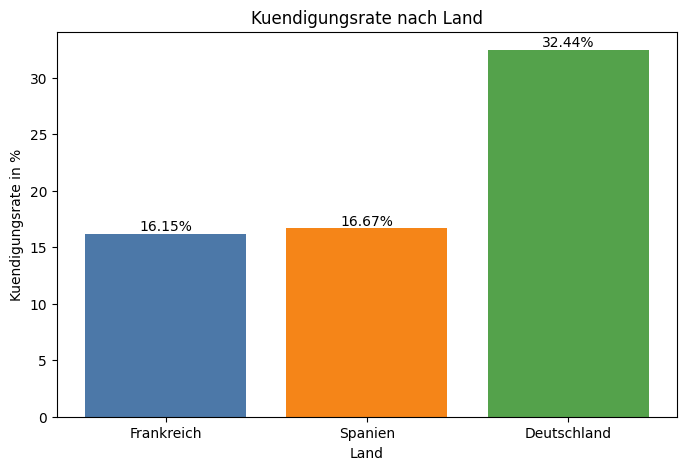

In [4]:
country_data = {}
for row in rows:
    country = row['Geography']
    exited = int(row['Exited'])
    if country not in country_data:
        country_data[country] = {'total': 0, 'exited': 0}
    country_data[country]['total'] += 1
    country_data[country]['exited'] += exited

country_names = {'France': 'Frankreich', 'Germany': 'Deutschland', 'Spain': 'Spanien'}
labels = []
values = []
for country, info in country_data.items():
    labels.append(country_names.get(country, country))
    values.append(round(info['exited'] / info['total'] * 100, 2))

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=['#4c78a8', '#f58518', '#54a24b'])
plt.title('Kuendigungsrate nach Land')
plt.xlabel('Land')
plt.ylabel('Kuendigungsrate in %')
for i, value in enumerate(values):
    plt.text(i, value + 0.3, str(value) + '%', ha='center')
plt.show()

## 2.4 Skalierung

Ich skaliere das Feld `Balance` mit der Z-Standardisierung. Das ist sinnvoll, weil die Werte dort sehr gross sein können. Danach liegen die Werte ungefähr um 0 herum.

In [5]:
balance_values = [float(row['Balance']) for row in rows]
balance_mean = statistics.mean(balance_values)
balance_std = statistics.stdev(balance_values)
scaled_balance = [round((value - balance_mean) / balance_std, 4) for value in balance_values]

print('Erste 10 originale Balance-Werte:')
print(balance_values[:10])
print('\nErste 10 skalierte Balance-Werte:')
print(scaled_balance[:10])
print('\nMittelwert skaliert:', round(statistics.mean(scaled_balance), 4))
print('Standardabweichung skaliert:', round(statistics.stdev(scaled_balance), 4))

Erste 10 originale Balance-Werte:
[0.0, 83807.86, 159660.8, 0.0, 125510.82, 113755.78, 0.0, 115046.74, 142051.07, 134603.88]

Erste 10 skalierte Balance-Werte:
[-1.2258, 0.1173, 1.333, -1.2258, 0.7857, 0.5973, -1.2258, 0.618, 1.0508, 0.9314]

Mittelwert skaliert: -0.0
Standardabweichung skaliert: 1.0


## Kurzfazit

Das Zielfeld ist `Exited`. Der Datensatz hat keine komplizierte Struktur und eignet sich gut für ein ML-Projekt. Es gibt sowohl numerische als auch kategoriale Felder. Mit der Grafik und der Skalierung ist Teil 2 erfüllt.